In [4]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np



In [12]:
# ==============================
# Excel file
# ==============================
excel_file = "Dilation.xlsx"

# Sheet names and dilation labels
sheets = {
    "ASPP246": "2,4,6",
    "ASPP4812": "4,8,12",
    "ASPP61218": "6,12,18",
    "ASPP369": "3,6,9"
}

In [13]:
# ==============================
# Function to compute F1 and IoU
# ==============================
def add_f1_iou(df):
    eps = 1e-7

    df["val_f1"] = (
        2 * df["val_precision"] * df["val_recall"]
    ) / (
        df["val_precision"] + df["val_recall"] + eps
    )

    df["val_iou"] = df["val_f1"] / (2 - df["val_f1"] + eps)

    return df


In [14]:
# ==============================
# Load all sheets and compute IoU
# ==============================
results = {}

for sheet, dilation in sheets.items():
    df = pd.read_excel(excel_file, sheet_name=sheet)
    df = add_f1_iou(df)
    results[dilation] = df

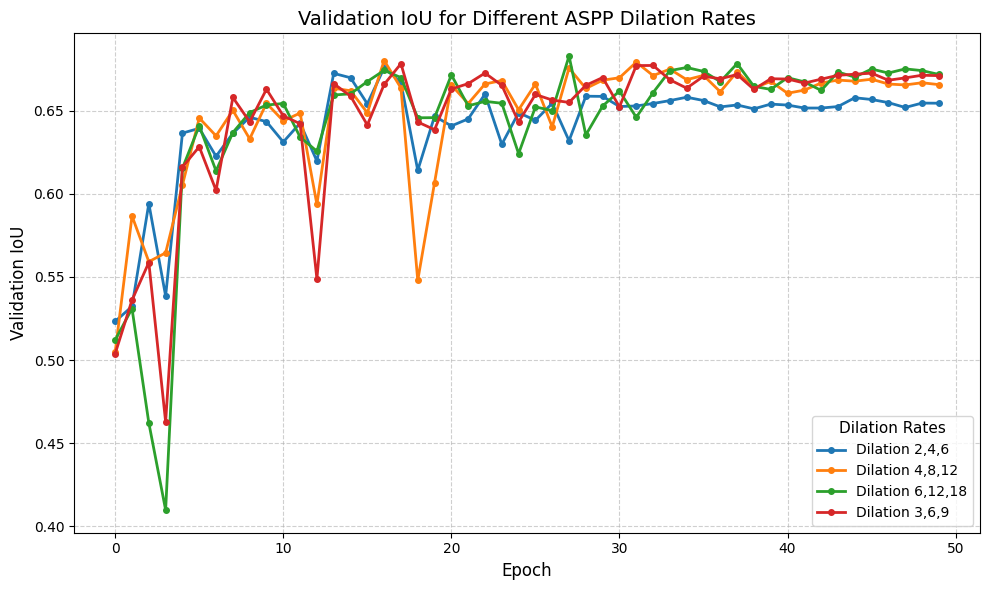

In [15]:
# ==============================
# Plot Validation IoU Curves
# ==============================

plt.figure(figsize=(10, 6))

for dilation, df in results.items():

    plt.plot(
        df["epoch"],
        df["val_iou"],
        linewidth=2,
        marker='o',
        markersize=4,
        label=f"Dilation {dilation}"
    )

# ==============================
# Labels and Title
# ==============================

plt.xlabel("Epoch", fontsize=12)
plt.ylabel("Validation IoU", fontsize=12)

plt.title(
    "Validation IoU for Different ASPP Dilation Rates",
    fontsize=14
)

# ==============================
# Legend
# ==============================

plt.legend(
    title="Dilation Rates",
    fontsize=10,
    title_fontsize=11,
    loc='lower right'
)

# ==============================
# Grid
# ==============================

plt.grid(True, linestyle='--', alpha=0.6)

# ==============================
# Save Figure
# ==============================

plt.tight_layout()

plt.savefig(
    "Dilation_Validation_IoU_Curves.png",
    dpi=300,
    bbox_inches="tight"
)

plt.savefig(
    "Dilation_Validation_IoU_Curves.pdf",
    bbox_inches="tight"
)

plt.show()

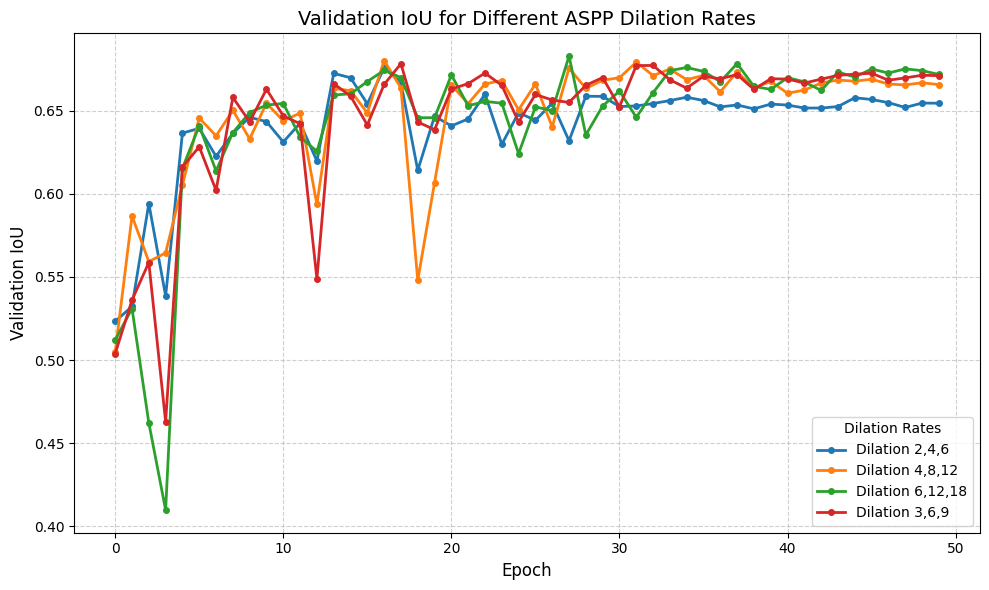

In [18]:
# ==============================
# Plot Validation IoU Curves
# ==============================

plt.figure(figsize=(10, 6))

for dilation, df in results.items():

    plt.plot(
        df["epoch"],
        df["val_iou"],
        linewidth=2,
        marker='o',
        markersize=4,
        label=f"Dilation {dilation}"
    )

# ==============================
# Labels
# ==============================

plt.xlabel("Epoch", fontsize=12)
plt.ylabel("Validation IoU", fontsize=12)

plt.title(
    "Validation IoU for Different ASPP Dilation Rates",
    fontsize=14
)

# ==============================
# Legend
# ==============================

plt.legend(
    title="Dilation Rates",
    loc="lower right",
    fontsize=10
)

# ==============================
# Grid
# ==============================

plt.grid(True, linestyle='--', alpha=0.6)

# ==============================
# Layout
# ==============================

plt.tight_layout()

# ==============================
# Save Figure
# ==============================

plt.savefig(
    "Dilation_Validation_IoU_Curves.png",
    dpi=300,
    bbox_inches="tight"
)

plt.savefig(
    "Dilation_Validation_IoU_Curves.pdf",
    bbox_inches="tight"
)

# ==============================
# Show
# ==============================

plt.show()

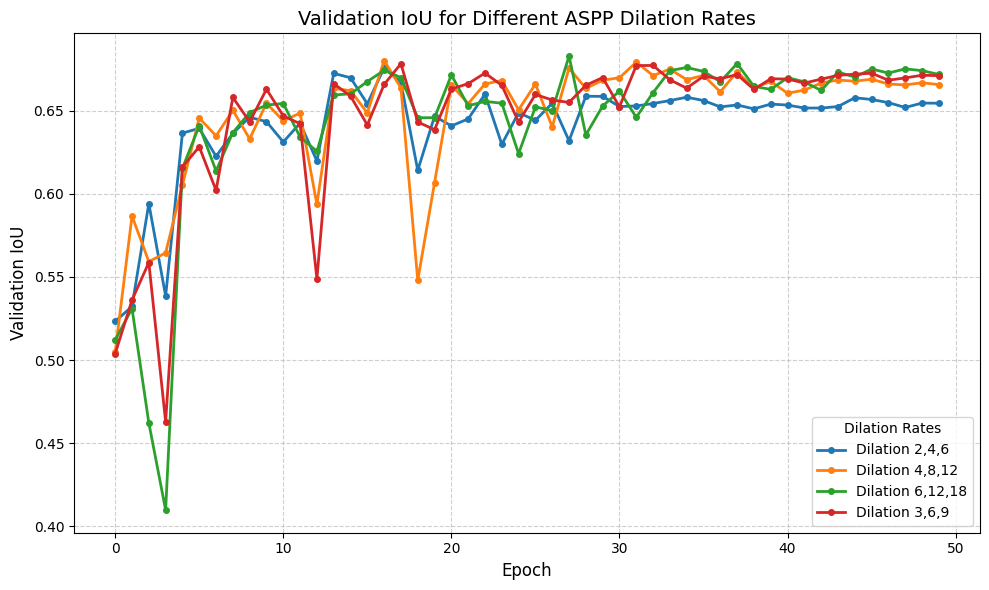

In [20]:
# ==============================
# Plot Validation IoU Curves
# ==============================

plt.figure(figsize=(10, 6))

for dilation, df in results.items():

    plt.plot(
        df["epoch"],
        df["val_iou"],
        linewidth=2,
        marker='o',
        markersize=4,
        label=f"Dilation {dilation}"
    )

# ==============================
# Labels
# ==============================

plt.xlabel("Epoch", fontsize=12)
plt.ylabel("Validation IoU", fontsize=12)

plt.title(
    "Validation IoU for Different ASPP Dilation Rates",
    fontsize=14
)

# ==============================
# Legend
# ==============================

plt.legend(
    title="Dilation Rates",
    loc="lower right",
    fontsize=10
)

# ==============================
# Grid
# ==============================

plt.grid(True, linestyle='--', alpha=0.6)

# ==============================
# Layout
# ==============================

plt.tight_layout()

# ==============================
# Save Figure
# ==============================

plt.savefig(
    "Dilation_Validation_IoU_Curves.png",
    dpi=300,
    bbox_inches="tight"
)

plt.savefig(
    "Dilation_Validation_IoU_Curves.pdf",
    bbox_inches="tight"
)

# ==============================
# Show
# ==============================

plt.show()

  Dilation  Best Validation IoU  Best Epoch
0    2,4,6             0.675723          16
1   4,8,12             0.680104          16
2  6,12,18             0.682794          27
3    3,6,9             0.678184          17
Dilation                object
Best Validation IoU    float64
Best Epoch               int64
dtype: object


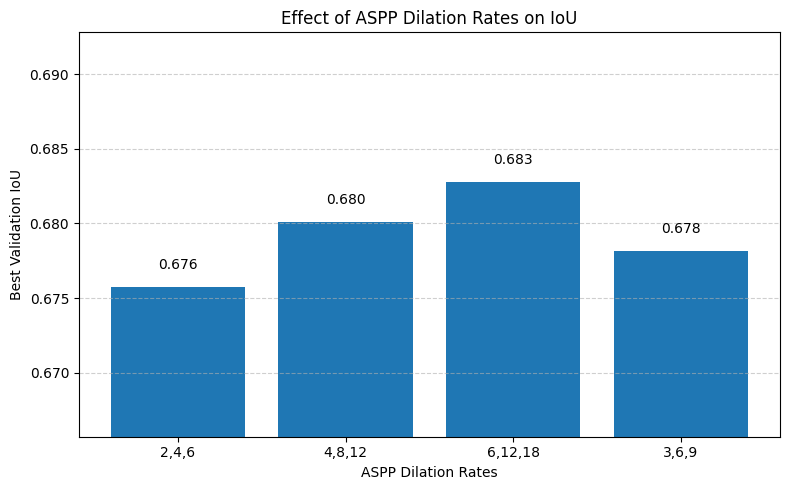

In [22]:
import pandas as pd
import matplotlib.pyplot as plt

# Check summary dataframe
print(summary_df)
print(summary_df.dtypes)

# Ensure IoU column is numeric
summary_df["Best Validation IoU"] = pd.to_numeric(
    summary_df["Best Validation IoU"],
    errors="coerce"
)

# Remove empty rows
summary_df = summary_df.dropna(subset=["Best Validation IoU"])

# Sort by dilation label if needed
summary_df = summary_df.reset_index(drop=True)

# ==============================
# Plot Best IoU Bar Chart
# ==============================
plt.figure(figsize=(8, 5))

bars = plt.bar(
    summary_df["Dilation"].astype(str),
    summary_df["Best Validation IoU"]
)

for bar in bars:
    height = bar.get_height()
    plt.text(
        bar.get_x() + bar.get_width() / 2,
        height + 0.001,
        f"{height:.3f}",
        ha="center",
        va="bottom",
        fontsize=10
    )

plt.xlabel("ASPP Dilation Rates")
plt.ylabel("Best Validation IoU")
plt.title("Effect of ASPP Dilation Rates on IoU")

# Use automatic y-limit based on values
y_min = summary_df["Best Validation IoU"].min() - 0.01
y_max = summary_df["Best Validation IoU"].max() + 0.01
plt.ylim(y_min, y_max)

plt.grid(axis="y", linestyle="--", alpha=0.6)
plt.tight_layout()

plt.savefig("Dilation_Best_IoU_BarChart.png", dpi=300, bbox_inches="tight")
plt.savefig("Dilation_Best_IoU_BarChart.pdf", bbox_inches="tight")

plt.show()